In [1]:
import os

GPU_NUM = 1
GPU_NUM = str(GPU_NUM)

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" 
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_NUM 

# torch를 CUDA_VISIBLE_DEVICES 뒤에 import 해야 제대로 설정됨.
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f'CUDA Device Name: {torch.cuda.get_device_name(0)}, GPU NUM: {GPU_NUM}')
else: print(device)

torch.cuda.empty_cache() 

CUDA Device Name: NVIDIA GeForce RTX 4090, GPU NUM: 1


In [2]:
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from pathlib import Path

import torch
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

In [3]:
from utils.utils import *
from utils.config import Config

In [4]:
cfg = Config(name='Dataset_MNIST_Clutter', data='Data_EchoNet-Dynamic')
print(cfg)

ECHO_DIR    = Path(cfg.data_path / cfg.data / 'frames')
SAVE_DIR = Path(cfg.base_path) / cfg.data / 'mnist'

----------------------------------------------------------------------
                        Config Details (Auto)                         
----------------------------------------------------------------------

[ Base Settings ]
  name                   : Dataset_MNIST_Clutter
  data                   : Data_EchoNet-Dynamic
  mkdir                  : False
  dtype                  : float64
  device                 : cpu
  multi_gpu              : False

[ Paths ]
  base_path              : /ds/mkseo/SM-Dehazing
  data_path              : /ds/mkseo/SM-Dehazing/data
  res_path               : /ds/mkseo/SM-Dehazing/res/Dataset_MNIST_Clutter
  fig_path               : /ds/mkseo/SM-Dehazing/res/Dataset_MNIST_Clutter/fig
  loss_path              : /ds/mkseo/SM-Dehazing/res/Dataset_MNIST_Clutter/loss
  model_path             : /ds/mkseo/SM-Dehazing/res/Dataset_MNIST_Clutter/model
----------------------------------------------------------------------


In [ ]:
def add_mnist_as_noise(echo_img, mnist_gpu, alpha=0.6):

    idx         = torch.randint(0, len(mnist_gpu), (1,), device=device).item()
    mnist_img   = mnist_gpu[idx].repeat(3, 1, 1)

    random_rgb  = torch.rand((3, 1, 1), device=device)
    mnist_rgb   = mnist_img * random_rgb

    noise_img   = echo_img + (mnist_rgb * alpha)
    noise_img   = torch.clamp(noise_img, 0, 1)

    return echo_img, mnist_rgb, noise_img

def tensor_to_uint8_img(x):
    return (x.permute(1, 2, 0).detach().cpu().numpy() * 255).astype(np.uint8)

def run_bulk_processing(frames, mnist_gpu, transform, alpha=0.6, check_visual=True, save=True):
    pbar = tqdm(frames, desc='Processing MNIST Clutter')
    
    echo_imgs, mnist_imgs, noise_imgs = [], [], []
    for echo_frame in pbar:
        name = echo_frame.split('.')[0]
        
        echo_img = Image.open(ECHO_DIR / echo_frame).convert('RGB')
        echo_img = transform(echo_img).to(device=device, non_blocking=True)

        echo, mnist, noise = add_mnist_as_noise(echo_img, mnist_gpu, alpha)

        if check_visual:
            pbar.clear()

            check_echo = tensor_to_uint8_img(echo)
            check_mnist = tensor_to_uint8_img(mnist)
            check_noise = tensor_to_uint8_img(noise)

            check_imgs  = [check_echo, check_mnist, check_noise]
            titles      = ['Echo', 'MNIST', 'Noise']

            plt.figure(figsize=(10, 4))
            for i, img in enumerate(check_imgs):
                plt.subplot(1, len(check_imgs), i+1)
                plt.imshow(img)
                plt.title(titles[i], fontsize=10)

            plt.tight_layout()
            plt.show()

            check_visual = False

        if save:
            save_path = SAVE_DIR / f'{name}.png'
            noise_img = tensor_to_uint8_img(noise)        
            noise_img = Image.fromarray(noise_img)
            noise_img.save(str(save_path), dpi=(500, 500))

        echo_imgs.append(tensor_to_uint8_img(echo)); mnist_imgs.append(tensor_to_uint8_img(mnist)); noise_imgs.append(noise_img)

        pbar.set_postfix(Sample=name)
    print('done.')

    return echo_imgs, mnist_imgs, noise_imgs

In [6]:
echo_frames = listdir(ECHO_DIR)
_shape      = transforms.ToTensor()(Image.open(ECHO_DIR / echo_frames[0])).shape
print(f'Echocardiogram Shape: {_shape}')

echo_transform  = transforms.Compose([
    transforms.Resize((_shape[1:])),
    transforms.ToTensor()
])

mnist_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.CenterCrop(_shape[1:]),
    transforms.ToTensor()
])

mnist_dataset   = torchvision.datasets.MNIST(root='./', train=True, download=True, transform=mnist_transform)
mnist_loader    = iter(DataLoader(mnist_dataset, batch_size=1, shuffle=True))

temp_list = []
for i in tqdm(range(len(mnist_dataset)), desc='Loading MNIST'):
    img, _ = mnist_dataset[i]
    temp_list.append(img)

mnist_gpu = torch.stack(temp_list).to(device)

Echocardiogram Shape: torch.Size([3, 112, 112])


Loading MNIST: 100%|██████████| 60000/60000 [00:10<00:00, 5759.91it/s]


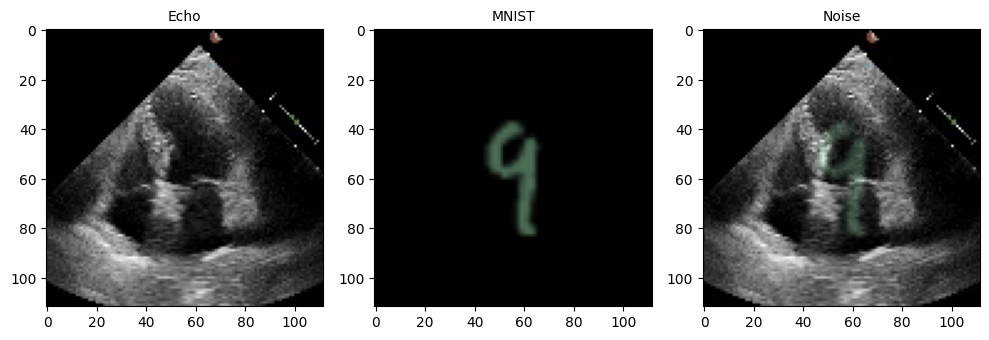

Processing MNIST Clutter: 100%|██████████| 30090/30090 [12:47<00:00, 39.21it/s, Sample=Patient_10030_F003]  


done.


In [ ]:
mk_dir(SAVE_DIR)

echos, mnists, noises = run_bulk_processing(echo_frames[0], mnist_gpu, echo_transform, save=False)

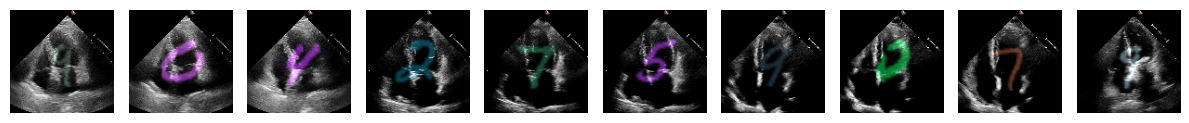

In [11]:
results = listdir(SAVE_DIR)
imgs = [Image.open(SAVE_DIR / results[i]) for i in range(10)]

plt.figure(figsize=(12, 5))
for i, img in enumerate(imgs):
    plt.subplot(1, len(imgs), i+1)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()